In [1]:
from chess_eval import *
sm = StorageManager()

In [2]:
one_dm = load_dataset("one")
one_full_dm = load_dataset("one_full")
one_full_rd_dm = load_dataset("one_full_rd")

## GBR

### `GBR_one`: GradientBoosting with `one` dataframe

In [3]:
grb_one_mm = ModelManager(
    model=GradientBoostingRegressor(random_state=RANDOM_STATE)
)
grb_one_mm.fit(one_dm)  # 20 seconds
sm.save_model(grb_one_mm, one_dm, "GBR_one")

'C:\\Users\\natan\\MatCAD\\3\\3.1\\Aprenentatge Computacional\\Chess Evaluations\\models\\GBR_one.pkl'

### `GBR_one_full`: GradientBoosting with `one_full` dataframe

In [ ]:
grb_one_full_mm = ModelManager(
    model=GradientBoostingRegressor(random_state=RANDOM_STATE)
)
grb_one_full_mm.fit(one_full_dm)
sm.save_model(grb_one_full_mm, one_full_dm, "GBR_one_full")

### `GBR_one_full_rd`: GradientBoosting with `one_full_rd` dataframe

In [ ]:
grb_one_full_rd_mm = ModelManager(
    model=GradientBoostingRegressor(random_state=RANDOM_STATE)
)
grb_one_full_rd_mm.fit(one_full_rd_dm)
sm.save_model(grb_one_full_rd_mm, one_full_rd_dm, "GBR_one_full_rd")

## MLPRegressor

In [5]:
mlpr_one_mm = ModelManager(
    model=MLPRegressor(max_iter=2000, random_state=RANDOM_STATE)
)
mlpr_one_mm.fit(one_dm)  # 23 minutes
sm.save_model(mlpr_one_mm, one_dm, "mlpr_one")

'C:\\Users\\natan\\MatCAD\\3\\3.1\\Aprenentatge Computacional\\Chess Evaluations\\models\\mlpr_one.pkl'

***

In [6]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

class FENMaterial64(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def _fen_to_vec(self, fen):
        # fen: string "board ...", we only need the board part
        board = fen.split()[0]
        rows = board.split("/")
        out = np.zeros(64, dtype=float)
        idx = 0

        for row in rows:
            for ch in row:
                if ch.isdigit():
                    idx += int(ch)
                else:
                    piece = ch.lower()
                    if piece == "p": v = 1
                    elif piece in ("n", "b"): v = 3
                    elif piece == "r": v = 5
                    elif piece == "q": v = 9
                    elif piece == "k": v = 0
                    else: raise ValueError(f"Invalid FEN piece: {ch}")

                    if ch.isupper():
                        out[idx] = v
                    else:
                        out[idx] = -v
                    idx += 1
        return out

    def fit(self, X, y=None):
        # X is a 1D array-like of FEN strings
        mats = np.array([self._fen_to_vec(fen) for fen in X])
        self.mean_ = mats.mean(axis=0)
        self.std_ = mats.std(axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self

    def transform(self, X):
        mats = np.array([self._fen_to_vec(fen) for fen in X])
        return (mats - self.mean_) / self.std_


In [7]:
raw_dm = DataManager(read_size=None, sample_size=100_000, random_state=RANDOM_STATE, transformers=None)

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor

pipe = Pipeline([
    ("fen64", FENMaterial64()),
    ("mlp", MLPRegressor(max_iter=2000, random_state=RANDOM_STATE))
])

pipe.fit(raw_dm.df[FEN], raw_dm.df[EVAL])

,steps,"[('fen64', ...), ('mlp', ...)]"
,transform_input,None
,memory,None
,verbose,False
,loss,'squared_error'
,hidden_layer_sizes,"(100,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'


In [13]:
from scipy.stats import spearmanr

y_pred = pipe.predict(raw_dm.df[FEN])

spearmanr(raw_dm.df[EVAL], y_pred)

SignificanceResult(statistic=np.float64(0.5827254972407905), pvalue=np.float64(0.0))

In [21]:
mm = ModelManager(model=pipe.named_steps["mlp"])

In [24]:
sm.save_model(mm, raw_dm, "MLPR_100k_rd", "use FENMaterial64 transformer")

'C:\\Users\\natan\\MatCAD\\3\\3.1\\Aprenentatge Computacional\\Chess Evaluations\\models\\MLPR_100k_rd.pkl'

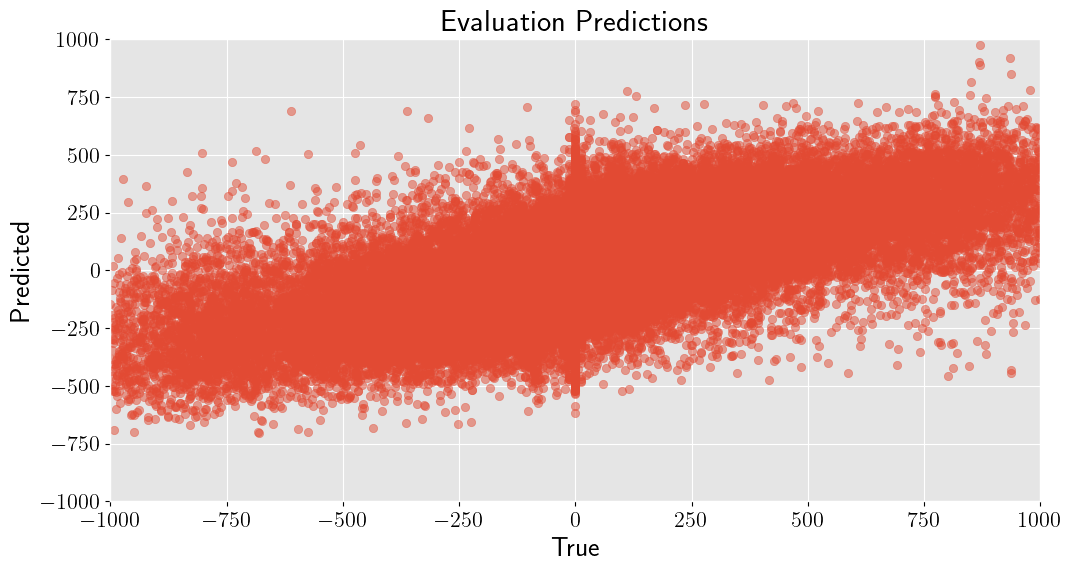

In [16]:
plt.scatter(raw_dm.df[EVAL], y_pred, alpha=0.5)
plt.xlim(-EVAL_THRESHOLD, EVAL_THRESHOLD)
plt.ylim(-EVAL_THRESHOLD, EVAL_THRESHOLD)
plt.xlabel("True")
plt.ylabel("Predicted")
plt.title("Evaluation Predictions")
plt.savefig("scatter_MLPR_FENMaterial64_100k_rd.png")